In [29]:
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
import os
import tensorflow_probability as tfp
tfd = tfp.distributions

tf.config.list_physical_devices('GPU')

[]

# importing data

In [15]:
df = pd.read_csv('../camels_info/camels_parameters.csv')
df

,Name,Omega_m,sigma_8,A_SN1,A_AGN1,A_SN2,A_AGN2,seed
0,LH_0,0.3090,0.9790,3.11234,1.12194,0.66850,0.53182,0
1,LH_1,0.3026,0.9394,3.42001,3.96137,1.03311,1.16070,1
2,LH_2,0.4282,0.7530,0.70613,0.37423,1.96292,0.62720,2
3,LH_3,0.1906,0.6286,1.60882,0.39887,0.86634,0.86634,3
4,LH_4,0.1382,0.6874,1.19914,0.27586,0.82188,0.91700,4
...,...,...,...,...,...,...,...,...
1092,CV_26,0.3000,0.8000,1.00000,1.00000,1.00000,1.00000,27
1093,EX_0,0.3000,0.8000,1.00000,1.00000,1.00000,1.00000,13560
1094,EX_1,0.3000,0.8000,1.00000,100.00000,1.00000,1.00000,13560
1095,EX_2,0.3000,0.8000,100.00000,1.00000,1.00000,1.00000,13560


In [16]:
df.loc[df['Name'] == "LH_0"].values[0][1:-1]

array([0.309, 0.979, 3.11234, 1.12194, 0.6685, 0.53182], dtype=object)

In [17]:
out_dir = "../power_spectra/CO/20230313_no_std/"

def get_LH_files():
    fils = list(map(lambda fil: fil[:-4], \
               (filter(lambda fil: f"LH_" in fil, os.listdir(out_dir)))))
    sorter_1P_fils = lambda filname: int(filname.split('_')[-1].replace('n', '-'))
    return sorted(fils, key=sorter_1P_fils)

sim_names = get_LH_files()
sim_names[:5], sim_names[-5:], len(sim_names)

(['LH_0', 'LH_1', 'LH_2', 'LH_3', 'LH_4'],
 ['LH_995', 'LH_996', 'LH_997', 'LH_998', 'LH_999'],
 1000)

In [18]:
if "LH_603" in sim_names:
    sim_names.remove("LH_603")

In [19]:
non_nan_range = np.arange(24, 46)
all_curves = np.array([])
k_set = None
for fil in sim_names:
    with np.load(out_dir + fil + ".npz", allow_pickle=True) as data:
        curves = data['curves'].item()
        redshifts = data['redshifts'].item()
        ks = data['ks'].item()
    nan_sum = sum(sum(np.isnan(np.array(list(curves.values()))))[non_nan_range])
    assert (nan_sum == 0), fil
    assert (sum(np.isnan(np.array(list(curves.values()))))[23] == 34)
    assert (sum(np.isnan(np.array(list(curves.values()))))[46] == 34)
    if k_set is None:
        k_set = ks[0]
    for k in ks.values():
        assert((k == k_set).all()), print(fil, k, k_set)

In [7]:
sim_names = sim_names[:603] + ["LH_603"] + sim_names[604:]
sim_names[600:605]

['LH_600', 'LH_601', 'LH_602', 'LH_603', 'LH_605']

In [161]:
num_samples = len(sim_names)
print(num_samples)
non_nan_range = np.arange(24, 46)
all_curves = np.zeros((num_samples, 34, 22)) + np.nan
all_cosmologies = np.zeros((num_samples, 6)) + np.nan
for ind, fil in enumerate(sim_names):
    with np.load(out_dir + fil + ".npz", allow_pickle=True) as data:
        curves = data['curves'].item()
        redshifts = data['redshifts'].item()
        ks = data['ks'].item()
    all_curves[ind] = np.array(list(curves.values()))[:, non_nan_range]
    all_cosmologies[ind] = df.loc[df['Name'] == fil].values[0][1:-1]

999


In [21]:
print(all_curves.shape, all_cosmologies.shape)
print(np.sum(np.isnan(all_curves)), np.sum(np.isnan(all_cosmologies)))

(999, 34, 22) (999, 6)
0 0


In [22]:
train_split, val_split, test_split = int(0.85*num_samples), \
            int(0.10*num_samples) + 1, int(0.05*num_samples) + 1

print(train_split, val_split, test_split, train_split+val_split+test_split)

train_x, val_x, test_x = np.split(all_curves, [train_split, train_split+val_split])
train_y, val_y, test_y = np.split(all_cosmologies, [train_split, train_split+val_split])

print(train_x.shape, val_x.shape, test_x.shape)
print(train_y.shape, val_y.shape, test_y.shape)

849 100 50 999
(849, 34, 22) (100, 34, 22) (50, 34, 22)
(849, 6) (100, 6) (50, 6)


In [17]:
train_y, val_y, test_y = train_y[:,:2], val_y[:,:2], test_y[:,:2]
print(train_y.shape, val_y.shape, test_y.shape)

(849, 2) (100, 2) (50, 2)


# Basic NN

In [43]:
# Define the input shape
input_shape = (34, 22) 
# Define the model
output_num = 6
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(512, activation='relu', input_shape=input_shape),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(output_num, activation='linear') # assuming 6 output parameters
])

# Compile the model
# model.compile(loss='mse', optimizer='adam')
model.compile(loss=tf.keras.losses.LogCosh(), optimizer='adam')

# Train the model
history = model.fit(train_x, train_y, epochs=10, validation_data=(val_x, val_y), verbose=1)

# Evaluate the model on the test set
test_loss = model.evaluate(test_x, test_y)
print('Test loss:', test_loss)

model.summary()

Epoch 1/10
27/27 [==============================] - 2s 32ms/step - loss: 0.3553 - val_loss: 0.2139
Epoch 2/10
27/27 [==============================] - 1s 27ms/step - loss: 0.2172 - val_loss: 0.1510
Epoch 3/10
27/27 [==============================] - 1s 26ms/step - loss: 0.1726 - val_loss: 0.1456
Epoch 4/10
27/27 [==============================] - 1s 27ms/step - loss: 0.1664 - val_loss: 0.1439
Epoch 5/10
27/27 [==============================] - 1s 26ms/step - loss: 0.1614 - val_loss: 0.1401
Epoch 6/10
27/27 [==============================] - 1s 27ms/step - loss: 0.1610 - val_loss: 0.1412
Epoch 7/10
27/27 [==============================] - 1s 26ms/step - loss: 0.1612 - val_loss: 0.1407
Epoch 8/10
27/27 [==============================] - 1s 28ms/step - loss: 0.1596 - val_loss: 0.1408
Epoch 9/10
27/27 [==============================] - 1s 27ms/step - loss: 0.1584 - val_loss: 0.1454
Epoch 10/10
2/2 [==============================] - 0s 7ms/step - loss: 0.1849
Test loss: 0.18486104905605316


2/2 [==============================] - 0s 5ms/step


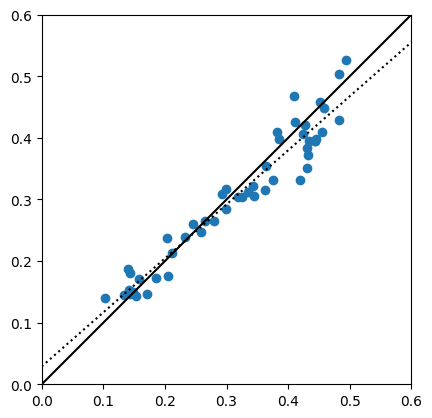

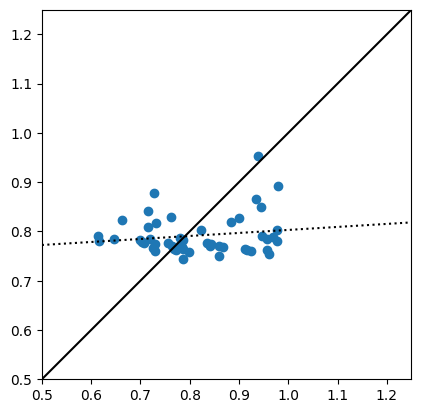

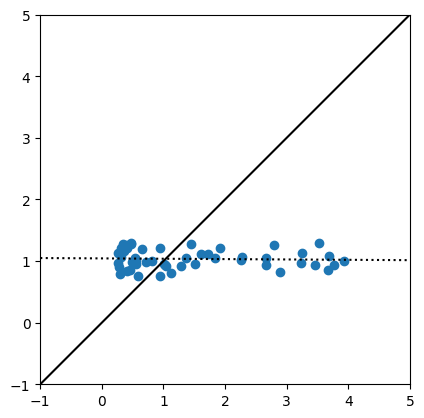

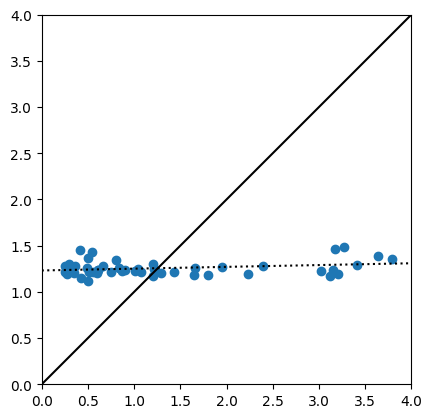

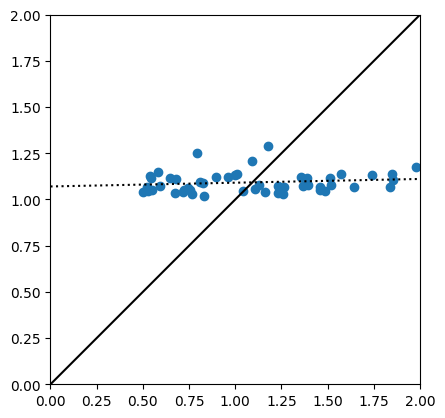

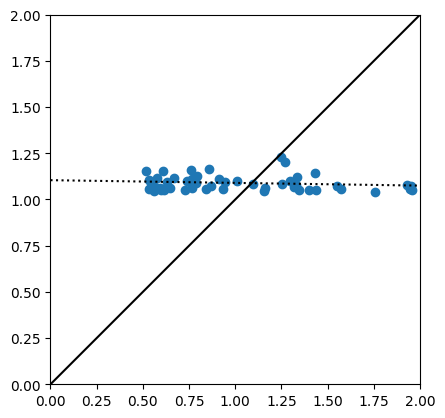

In [44]:
predictions = model.predict(test_x)
upp_lims = [0.6, 1.25, 5, 4, 2, 2]
low_lims = [0, 0.5, -1, 0, 0, 0]
for ind, (low_lim, upp_lim) in enumerate(zip(low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(test_y[:, ind], predictions[:, ind], 1))
    plt.figure()
    plt.scatter(test_y[:, ind], predictions[:, ind])
    plt.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    plt.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    plt.xlim([low_lim, upp_lim])
    plt.ylim([low_lim, upp_lim])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.show()
    plt.close()

# CNN

In [162]:
train_split, val_split, test_split = int(0.85*num_samples), \
            int(0.10*num_samples) + 1, int(0.05*num_samples) + 1

print(train_split, val_split, test_split, train_split+val_split+test_split)

train_x, val_x, test_x = np.split(all_curves, [train_split, train_split+val_split])
train_y, val_y, test_y = np.split(all_cosmologies, [train_split, train_split+val_split])

print(train_x.shape, val_x.shape, test_x.shape)
print(train_y.shape, val_y.shape, test_y.shape)

output_num = 1

train_y, val_y, test_y = train_y[:,:output_num], val_y[:,:output_num], test_y[:,:output_num]
print(train_y.shape, val_y.shape, test_y.shape)

849 100 50 999
(849, 34, 22) (100, 34, 22) (50, 34, 22)
(849, 6) (100, 6) (50, 6)
(849, 1) (100, 1) (50, 1)


In [165]:
input_shape = (34, 22, 1) 

model = tf.keras.Sequential([
  tf.keras.layers.Conv2D(512, kernel_size=(2, 2), activation='relu', input_shape=input_shape),
  tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
  tf.keras.layers.Conv2D(512, kernel_size=(3, 3), activation='relu'),
  tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
  tf.keras.layers.Conv2D(512, kernel_size=(4, 4), activation='relu'),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(256, activation='leaky_relu'),
  tf.keras.layers.Dense(256, activation='leaky_relu'),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dense(output_num, activation='linear') # assuming 6 output parameters
])

# Compile the model
# model.compile(loss='mse', optimizer='adam')
model.compile(loss=tf.keras.losses.LogCosh(), optimizer='adam')

# Train the model
history = model.fit(train_x, train_y, epochs=5, validation_data=(val_x, val_y), verbose=1)

# Evaluate the model on the test set
test_loss = model.evaluate(test_x, test_y)
print('Test loss:', test_loss)

model.summary()

Epoch 1/5
27/27 [==============================] - 9s 325ms/step - loss: 20.7980 - val_loss: 0.0206
Epoch 2/5
27/27 [==============================] - 8s 312ms/step - loss: 0.0233 - val_loss: 0.0063
Epoch 3/5
27/27 [==============================] - 8s 307ms/step - loss: 0.0043 - val_loss: 0.0021
Epoch 4/5
27/27 [==============================] - 8s 300ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 5/5
2/2 [==============================] - 0s 45ms/step - loss: 0.0013
Test loss: 0.0013070523273199797
Model: "sequential_58"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_62 (Conv2D)          (None, 33, 21, 512)       2560      
                                                                 
 max_pooling2d_40 (MaxPoolin  (None, 16, 10, 512)      0         
 g2D)                                                            
                                                                 
 conv2d_

2/2 [==============================] - 0s 18ms/step


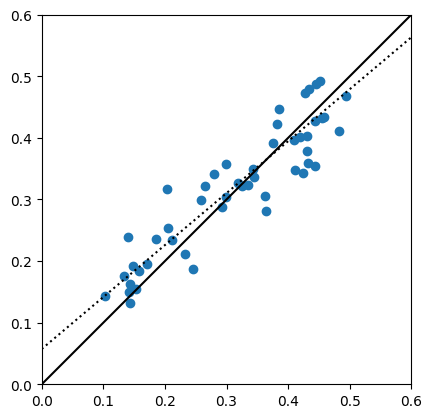

IndexError: index 1 is out of bounds for axis 1 with size 1

In [166]:
predictions = model.predict(test_x)
upp_lims = [0.6, 1.25, 5, 4, 2, 2]
low_lims = [0, 0.5, -1, 0, 0, 0]
for ind, (low_lim, upp_lim) in enumerate(zip(low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(test_y[:, ind], predictions[:, ind], 1))
    plt.figure()
    plt.scatter(test_y[:, ind], predictions[:, ind])
    plt.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    plt.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    plt.xlim([low_lim, upp_lim])
    plt.ylim([low_lim, upp_lim])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.show()
    plt.close()

In [40]:
np.sqrt(np.mean(((test_y[:, 0] - predictions[:, 0])) ** 2))

0.05648826767949644

In [41]:
np.sqrt(np.mean(((test_y[:, 1] - predictions[:, 1])) ** 2))

0.06106689420914096

In [42]:
np.sqrt(np.mean(((test_y[:, 2] - predictions[:, 2])) ** 2))

1.1867826771734458

# BNN

In [144]:
input_shape = (34, 22, 1) 

output_num = 6

negloglik = lambda y, rv_y: -rv_y.log_prob(y)

# Build model.
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(512, kernel_size=(2, 2), activation='relu', input_shape=input_shape),
  tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
  tf.keras.layers.Conv2D(512, kernel_size=(3, 3), activation='relu'),
  tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
  tf.keras.layers.Conv2D(512, kernel_size=(4, 4), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512),
    tf.keras.layers.Dense(512),
    tf.keras.layers.Dense(512),
    tf.keras.layers.Dense(512),
  tf.keras.layers.Dense(1 + 1),
  tfp.layers.DistributionLambda(
      lambda t: tfd.Normal(loc=t[..., :1],
                           scale=1e-3 + tf.math.softplus(0.05 * t[...,1:]))),
])

# Do inference.
model.compile(optimizer=tf.optimizers.Adam(), loss=negloglik)
model.fit(train_x, train_y, epochs=10, verbose=1, validation_data=(val_x, val_y))

# Evaluate the model on the test set
test_loss = model.evaluate(test_x, test_y)
print('Test loss:', test_loss)

model.summary()

Epoch 1/10
27/27 [==============================] - 9s 312ms/step - loss: 31809036288.0000 - val_loss: 873.0871
Epoch 2/10
27/27 [==============================] - 8s 299ms/step - loss: 781.5314 - val_loss: 279.9521
Epoch 3/10
27/27 [==============================] - 8s 288ms/step - loss: 59.5255 - val_loss: 14.4852
Epoch 4/10
27/27 [==============================] - 8s 300ms/step - loss: 13.9593 - val_loss: 13.1435
Epoch 5/10
27/27 [==============================] - 8s 298ms/step - loss: 12.9731 - val_loss: 12.9447
Epoch 6/10
27/27 [==============================] - 8s 301ms/step - loss: 12.9008 - val_loss: 12.9214
Epoch 7/10
27/27 [==============================] - 8s 297ms/step - loss: 12.8874 - val_loss: 12.9101
Epoch 8/10
27/27 [==============================] - 8s 297ms/step - loss: 12.8755 - val_loss: 12.8976
Epoch 9/10
27/27 [==============================] - 8s 304ms/step - loss: 12.8629 - val_loss: 12.8846
Epoch 10/10
2/2 [==============================] - 0s 31ms/step - loss

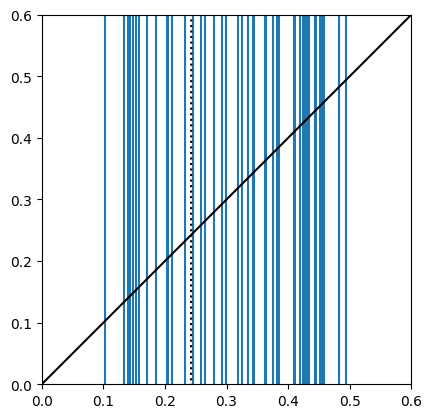

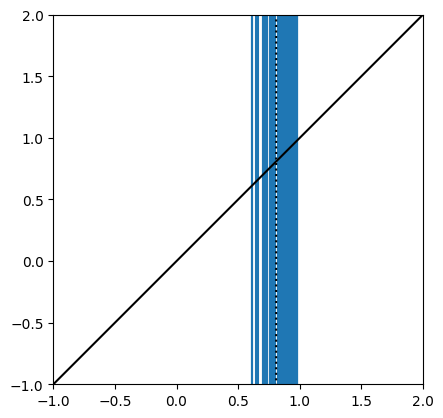

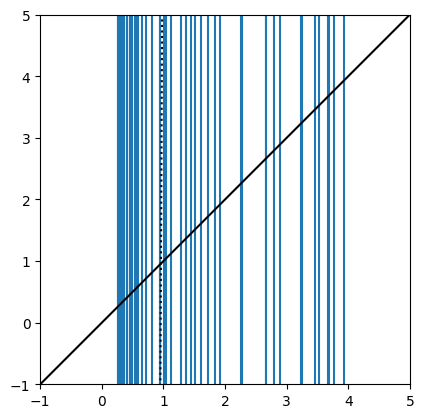

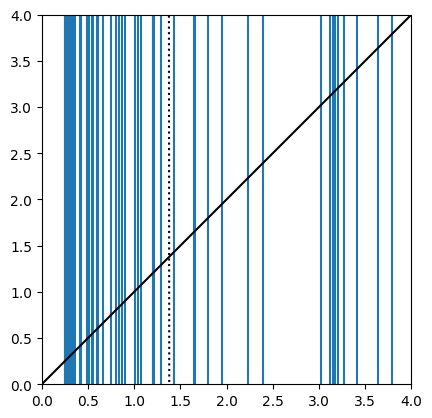

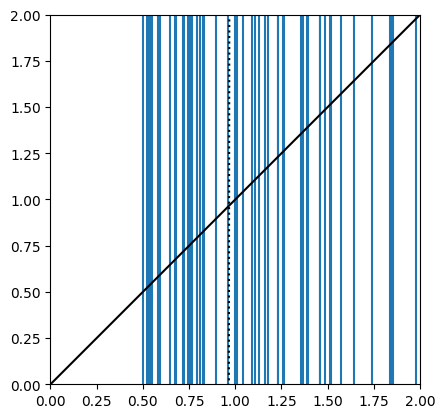

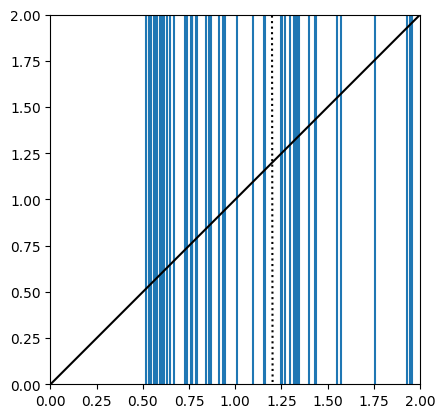

In [146]:
samples = 1000
predictions = np.zeros((samples, len(test_y), 6))
for ind in range(samples):
    predictions[ind] = model.predict(test_x, verbose=0)
predictions_mean = np.nanmean(predictions, axis=0)
predictions_std = np.nanstd(predictions, axis=0)

upp_lims = [0.6, 2, 5, 4, 2, 2]
low_lims = [0, -1, -1, 0, 0, 0]
for ind, (low_lim, upp_lim) in enumerate(zip(low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(test_y[:, ind], predictions_mean[:, ind], 1))
    plt.figure()
    plt.errorbar(test_y[:, ind], predictions_mean[:, ind], predictions_std[:, ind], ls="none")
    plt.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    plt.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    plt.xlim([low_lim, upp_lim])
    plt.ylim([low_lim, upp_lim])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.show()
    plt.close()